### EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [15]:
df=pd.read_csv("youtube_data.csv")

In [16]:
df

,Unnamed: 0,video_id,views,likes,comments,channel_id,channel_name,date,duration,category_id,genre,subscribers,engagement_rate,saturation_index,competition_density,roi_potential,subscriber_barrier,year_and_month,growth_rate
0,0,9_WBQISVHnw,2307901697,2719637,0,UCK5Q72Uyo73uRPk8PmM2A3w,Genevieve's Playhouse - Learning Videos for Kids,2019-01-05 16:52:49+00:00,623,1,Education,49200000.0,0.117840,1004.140551,0.135774,2.003063e+09,2.349722e+06,2019-01,488.235294
1,1,CnSylwYOu1E,2178021347,20943413,0,UCgFXm4TI8htWmCyJ6cVPG_A,Toys and Colors,2023-05-05 11:30:04+00:00,30,24,Entertainment,82000000.0,0.961580,324.014841,0.079748,2.626210e+10,1.241532e+07,2023-05,596.666667
2,2,hTqtGJwsJVE,1814220195,2853557,0,UCG2CL6EUjG8TVT1Tpl9nJdg,Ms Rachel - Toddler Learning Videos,2022-03-02 17:30:10+00:00,3621,27,Education,18600000.0,0.157288,1004.140551,0.135774,2.101698e+09,2.349722e+06,2022-03,488.235294
3,3,dNCWe_6HAM8,1184538229,15369289,1116739,UCOmHUn--16B90oW2L6FRR3A,BLACKPINK,2021-09-23 15:00:16+00:00,171,10,Finance,99700000.0,1.391768,1388.465336,0.148073,1.113370e+10,4.319394e+06,2021-09,473.333333
4,4,GQTUYAhJzY8,1128446716,17865538,44657,UCIH9-O5pX3Qr9bESZB3LYdw,Littos Media,2024-03-20 13:27:10+00:00,15,26,Education,8480000.0,1.587155,1004.140551,0.135774,1.319119e+10,2.349722e+06,2024-03,488.235294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7981,7981,Qe_dHjcRarw,1,0,0,UCQWWQGItM_0gON7SpwVE4Vw,Dexa,2026-01-15 14:25:08+00:00,19,22,Technology,6.0,0.000000,1916.096131,0.148733,0.000000e+00,4.491977e+06,2026-01,371.698113
7982,7982,n32p7IvPjJA,1,0,0,UCi897JrsWy7h46W6EQWQDMw,Fit with Suraj,2026-01-22 05:52:58+00:00,13,17,Fitness,155.0,0.000000,2194.906902,0.106005,0.000000e+00,1.451992e+06,2026-01,1500.000000
7983,7983,dyqJPxHGj5c,1,0,0,UC4vN_iXfrms4uvDkpQ4rw7Q,Skillvion,2026-01-18 12:45:31+00:00,412,27,Education,89.0,0.000000,1004.140551,0.135774,0.000000e+00,2.349722e+06,2026-01,488.235294
7984,7984,R1KN6mN0gZs,1,0,0,UC3VZb2ti0GDQCh9tk7agrRQ,TechyHub,2026-01-09 06:36:28+00:00,142,22,Technology,0.0,0.000000,1916.096131,0.148733,0.000000e+00,4.491977e+06,2026-01,371.698113


In [21]:
genre_metrics = df.groupby('genre').agg({
    'engagement_rate': 'mean',
    'saturation_index': 'first',
    'competition_density': 'first',
    'roi_potential': 'mean',
    'views': 'mean',
    'subscribers': 'mean',
    'video_id': 'count'
}).round(2)

genre_metrics.columns = ['avg_engagement_rate', 'saturation_index', 
                          'competition_density', 'avg_roi_potential',
                          'avg_views', 'avg_subscribers', 'video_count']

# Calculates barrier for new creators (subscriber barrier)
genre_metrics['creator_barrier'] = genre_metrics['avg_subscribers']

# Calculates business score (high ROI + high views)
genre_metrics['business_score'] = (
    (genre_metrics['avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 50) +
    (genre_metrics['avg_views'] / genre_metrics['avg_views'].max() * 30) +
    (genre_metrics['avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 20)
)

# Calculates creator score (high ROI + low barrier)
genre_metrics['creator_score'] = (
    (genre_metrics['avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 40) +
    ((1 / genre_metrics['creator_barrier']) * 1000000 * 40) +
    (genre_metrics['avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 20)
)


print(genre_metrics)


               avg_engagement_rate  saturation_index  competition_density  \
genre                                                                       
Beauty                        2.41           1189.19                 0.12   
Education                     2.70           1004.14                 0.14   
Entertainment                 1.58            324.01                 0.08   
Finance                       2.94           1388.47                 0.15   
Fitness                       2.10           2194.91                 0.11   
Gaming                        1.97           1079.19                 0.10   
Technology                    2.98           1916.10                 0.15   
Vlogs                         3.20           2194.64                 0.16   

               avg_roi_potential    avg_views  avg_subscribers  video_count  \
genre                                                                         
Beauty              2.012429e+08  12153022.08       2486493.94         

In [22]:
# 1. CALCULATE AVERAGE ROI POTENTIAL BY GENRE

genre_potential = df.groupby('genre').agg({
    'roi_potential': 'mean',
    'views': 'mean',
    'engagement_rate': 'mean',
    'competition_density': 'mean',
    'saturation_index': 'first',
    'video_id': 'count'
}).round(2)

genre_potential.columns = ['avg_roi_potential', 'avg_views', 'avg_engagement', 
                           'competition', 'saturation', 'video_count']

# Sort by ROI potential
genre_potential = genre_potential.sort_values('avg_roi_potential', ascending=False)

print(" Genres based on ROI POTENTIAL")

print(genre_potential)

 Genres based on ROI POTENTIAL
               avg_roi_potential    avg_views  avg_engagement  competition  \
genre                                                                        
Entertainment       6.699601e+08  44693072.30            1.58         0.08   
Gaming              2.549436e+08  13418601.17            1.97         0.10   
Beauty              2.012429e+08  12153022.08            2.41         0.12   
Technology          1.398877e+08   7489649.15            2.98         0.15   
Finance             1.382048e+08  10419228.43            2.94         0.15   
Fitness             1.212418e+08   6591048.34            2.10         0.11   
Education           1.063713e+08  14407084.24            2.70         0.14   
Vlogs               7.949338e+07   6598437.24            3.20         0.16   

               saturation  video_count  
genre                                   
Entertainment      324.01         1000  
Gaming            1079.19         1000  
Beauty            1189.1

## Insights
* Entertainment has the maximum ROI Potential
* Average ROI Potential: 669,591,339.81
* Average Views: 44,693,072
* Average Engagement: 1.58%
* Competition Density: 0.08

In [23]:
# Set style
sns.set_style("whitegrid")
plt.rcPdfarams['figure.figsize'] = (16, 20)

fig = plt.figure(figsize=(20, 24))

# Define color palette
colors = sns.color_palette("husl", len(df))
genre_colors = {genre: color for genre, color in zip(df.index, colors)}

<Figure size 2000x2400 with 0 Axes>

## 1. ENGAGEMENT RATE


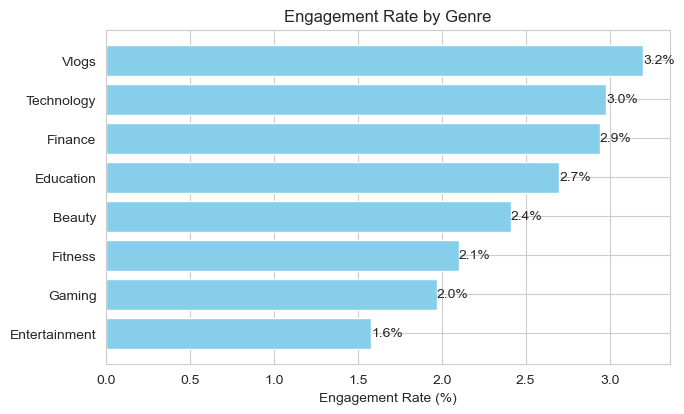

In [25]:

ax1 = plt.subplot(4, 2, 1)

engagement_sorted = genre_metrics.sort_values('avg_engagement_rate', ascending=True)
ax1.barh(engagement_sorted.index, engagement_sorted['avg_engagement_rate'], color='skyblue')

ax1.set_xlabel('Engagement Rate (%)')
ax1.set_title('Engagement Rate by Genre')

for i, v in enumerate(engagement_sorted['avg_engagement_rate']):
    ax1.text(v, i, f'{v:.1f}%', va='center')


### Key Findings

- **Vlogs (3.2%)**  has the **highest engagement rate** which means there is a strong personal connection with audiences.

- **Entertainment (1.6%)** has the **Lowest engagement** despite having high viewership.
  
#### Observations

1. Educational and personal content such Vlogs, Tech, Finance etc. drives higher interaction than entertainment-focused content
2. Genres requiring advice, learning, or personal connection show stronger engagement patterns


## 2. SATURATION INDEX

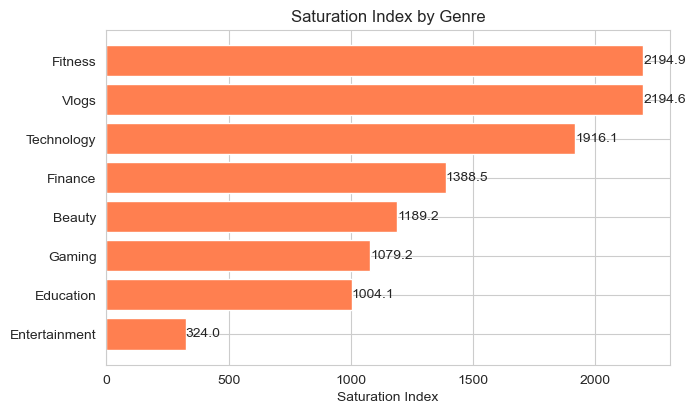

In [26]:
ax2 = plt.subplot(4, 2, 2)

saturation_sorted = genre_metrics.sort_values('saturation_index', ascending=True)
ax2.barh(saturation_sorted.index, saturation_sorted['saturation_index'], color='coral')

ax2.set_xlabel('Saturation Index')
ax2.set_title('Saturation Index by Genre')

for i, v in enumerate(saturation_sorted['saturation_index']):
    ax2.text(v, i, f'{v:.1f}', va='center')

## 3. COMPETITION DENSITY

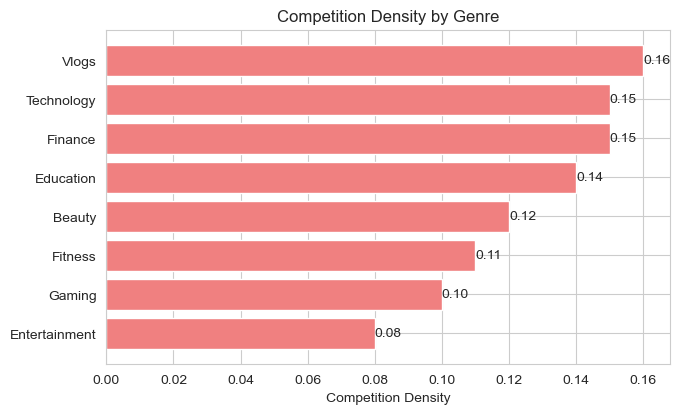

In [28]:
ax3 = plt.subplot(4, 2, 3)

competition_sorted = genre_metrics.sort_values('competition_density', ascending=True)
ax3.barh(competition_sorted.index, competition_sorted['competition_density'], color='lightcoral')

ax3.set_xlabel('Competition Density')
ax3.set_title('Competition Density by Genre')

for i, v in enumerate(competition_sorted['competition_density']):
    ax3.text(v, i, f'{v:.2f}', va='center')


### Key Findings

#### High Competition Genres
- **Vlogs (0.16)** has the highest competition density and most crowded competitive landscape.
- **Technology (0.15)** is the second highest as well as intense competition among tech creators,

#### Lower Competition Genres
- **Gaming (0.10)** has below-average competition despite having a large market size.
- **Entertainment (0.08)** has Lowest competition density and least crowded relative to market.

#### Observations
- Personal content genres like Vlogs, Finance etc., face higher direct competition.
- Entertainment and Gaming show lower density although they are popular categories
- Education maintains moderate-to-high competition levels


## 4. ROI POTENTIAL

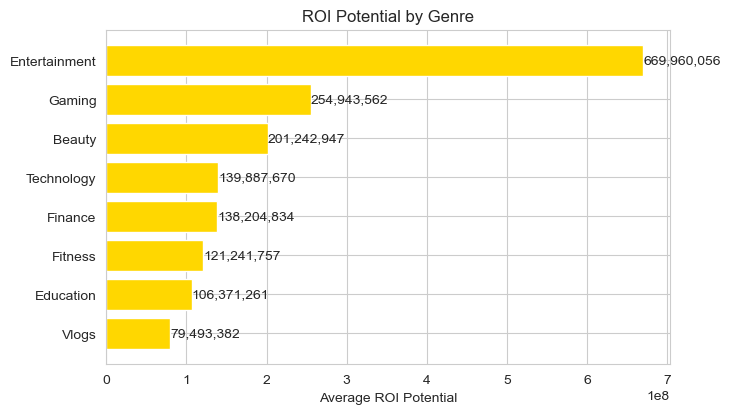

In [30]:
ax4 = plt.subplot(4, 2, 4)

roi_sorted = genre_metrics.sort_values('avg_roi_potential', ascending=True)
ax4.barh(roi_sorted.index, roi_sorted['avg_roi_potential'], color='gold')

ax4.set_xlabel('Average ROI Potential')
ax4.set_title('ROI Potential by Genre')

for i, v in enumerate(roi_sorted['avg_roi_potential']):
    ax4.text(v, i, f'{v:,.0f}', va='center')

### Key Findings

#### High ROI Genres
- **Entertainment (669,591,340)** dominantes the ROI leaderboard.
- **Gaming (254,803,253)** shows strong ROI potential and significantly above other genres.
- **Beauty (201,132,192)** Third highest showing that their is a solid monetization opportunity.

#### Lower ROI Genre
- **Vlogs (79,449,632)** has Lowest ROI potential althought it has the high engagement rates.

#### Observations
1. Entertainment generates 8.4x more ROI than Vlogs
2. Vlogs have highest engagement (3.2%) but lowest ROI
4. Niche genres like Finance, Education show moderate ROI despite having a specialized audiences.
5. Personal contents such as Vlogs struggles with monetization despite having strong engagement.

## 5. BUSINESS SCORE(For bussinesses)

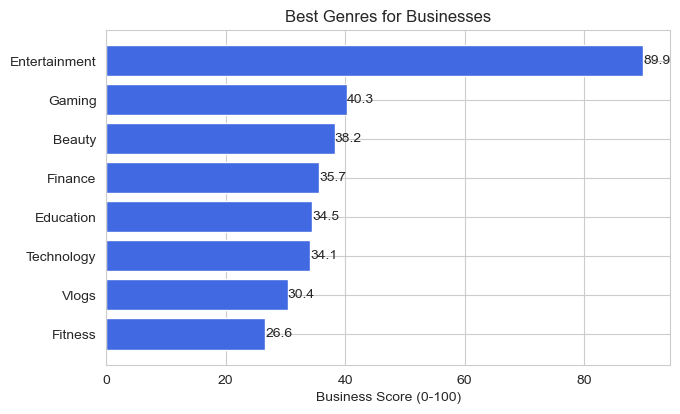

In [33]:
ax5 = plt.subplot(4, 2, 5)

business_sorted = genre_metrics.sort_values('business_score', ascending=True)
ax5.barh(business_sorted.index, business_sorted['business_score'], color='royalblue')

ax5.set_xlabel('Business Score (0-100)')
ax5.set_title('Best Genres for Businesses')

for i, v in enumerate(business_sorted['business_score']):
    ax5.text(v, i, f'{v:.1f}', va='center')

### Key Findings

#### Top Business Opportunities
- **Entertainment (89.9)** leads for business content charts
- **Gaming (40.3)** comes at second showing a moderate business opportunity
- **Beauty (38.2)** comes at third place feasable for product-focused businesses.

#### Lower Business Opportunities
- **Vlogs (30.4)** showes below-average business viability.
- **Fitness (26.6)** has the lowest business score despite its market size.

#### Key Observations
1. Business success correlates more with reach than interaction
4. Entertainment's broad appeal translates to superior business metrics

## 6. Creator Barrier

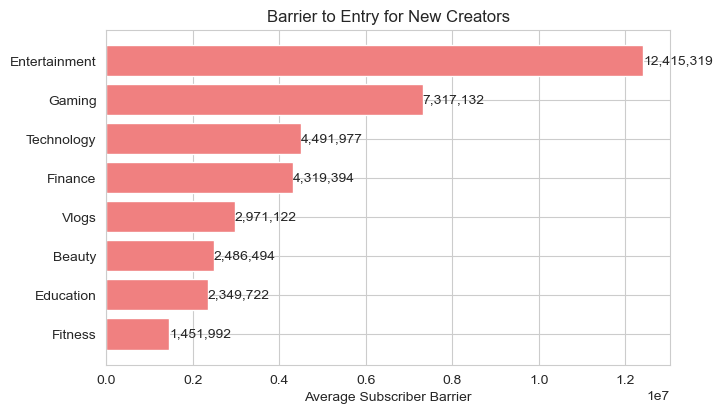

In [35]:
ax6 = plt.subplot(4, 2, 6)

barrier_sorted = genre_metrics.sort_values('creator_barrier', ascending=True)
ax6.barh(barrier_sorted.index, barrier_sorted['creator_barrier'], color='lightcoral')

ax6.set_xlabel('Average Subscriber Barrier')
ax6.set_title('Barrier to Entry for New Creators')

for i, v in enumerate(barrier_sorted['creator_barrier']):
    ax6.text(v, i, f'{v:,.0f}', va='center')

### Key Findings

#### High Barrier Genres (Difficult Entry)
- **Entertainment (12,415,319)** shows highest barrier for aspiring creators which will require massive subscriber base to compete.
- **Gaming (7,317,132)** is the second highest and will need a substantial audience.

#### Low Barrier Genres (Easier Entry)
- **Education (2,349,722)** has a Lower barrier possible for  knowledge-based entry.
- **Fitness (1,451,992)** has the lowest barrier and is the most accessible for new creators.

#### Observations
1. Entertainment requires 8.5x more subscribers than Fitness to compete.
2. High ROI genres like Entertainment, Gaming etc., have the highest entry barriers.
3. Skill-based genres like Fitness, Education have lower barriers


## 7. CREATOR SCORE (Best for New Creators)

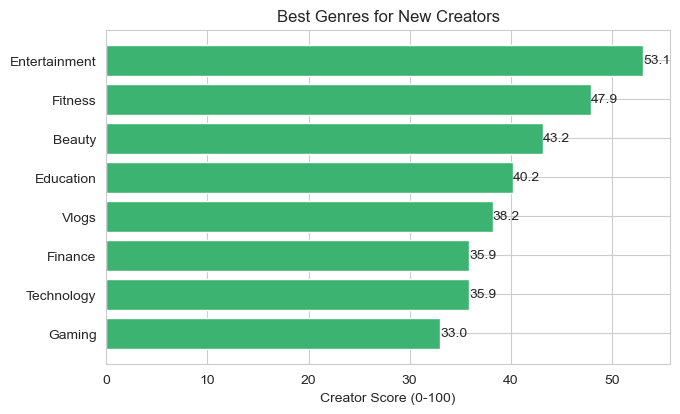

In [36]:
ax7 = plt.subplot(4, 2, 7)

creator_sorted = genre_metrics.sort_values('creator_score', ascending=True)
ax7.barh(creator_sorted.index, creator_sorted['creator_score'], color='mediumseagreen')

ax7.set_xlabel('Creator Score (0-100)')
ax7.set_title('Best Genres for New Creators')

for i, v in enumerate(creator_sorted['creator_score']):
    ax7.text(v, i, f'{v:.1f}', va='center')

### Key Findings

#### Top Creator Opportunities
- **Entertainment (53.1)** has the Best overall opportunity for new creators despite high entry barrier.
- **Fitness (47.9)** secures the second place and gets benefited from lowest entry barrier.
- **Beauty (43.2)** comes third place and shows a balanced opportunity.

#### Lower Creator Opportunity
- **Gaming (33.0)** has the lowest creator score, despite having high business potential, is difficult for new entrants.

#### Observations
1. Entertainment's massive ROI (670M) overcomes its high entry barrier for ambitious creators
2. Fitness offers best risk-reward balance (low barrier + high score)
3. Gaming least favorable for new creators despite commercial success
4. Low barriers don't guarantee high creator scores (e.g Education 40.2 vs Entertainment 53.1)

#### Creator Archetypes
- **High Risk/High Reward**: Entertainment (high barrier, highest score)
- **Balanced Entry**: Fitness, Beauty (moderate barriers, strong scores)
- **Knowledge-Based**: Education (low barrier, moderate score)
- **Avoid for Newcomers**: Gaming (high barrier, lowest score)

## 8. BUSINESS vs CREATOR 


✓ Visualization saved as 'genre_analysis.png'


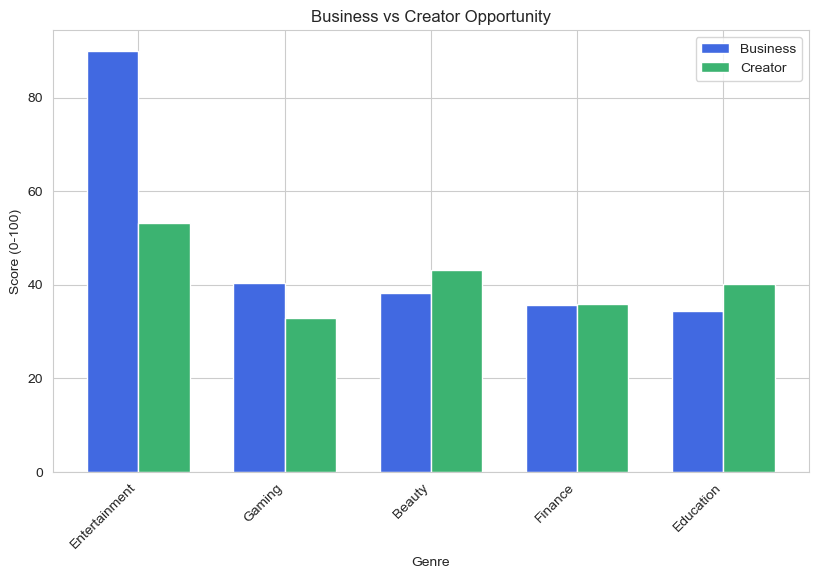

In [37]:
ax8 = plt.subplot(4, 2, 8)

top_genres = genre_metrics.nlargest(5, 'business_score').index
x = np.arange(len(top_genres))
width = 0.35

business_scores = genre_metrics.loc[top_genres, 'business_score']
creator_scores = genre_metrics.loc[top_genres, 'creator_score']


ax8.bar(x - width/2, business_scores, width, label='Business', color='royalblue')
ax8.bar(x + width/2, creator_scores, width, label='Creator', color='mediumseagreen')


ax8.set_xlabel('Genre')
ax8.set_ylabel('Score (0-100)')
ax8.set_title('Business vs Creator Opportunity')
ax8.set_xticks(x)
ax8.set_xticklabels(top_genres, rotation=45, ha='right')
ax8.legend()

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'genre_analysis.png'")

### Business vs Creator Opportunity - Key Findings

#### Entertainment
- **Business Score**: 89.9 (Dominant leader) and **Creator Score**: 53.1 (Also highest for creators)
-  Strong for both, but exceptionally better for businesses

#### Gaming
- **Business Score**: 40.3 (Second for businesses) and **Creator Score**: 33.0 (Lowest for creators)
-  Better business opportunity than creator opportunity 

#### Beauty
- **Business Score**: 38.2 (Third for businesses) and **Creator Score**: 43.2 (Third for creators)
- Better for creators than businesses

#### Education
- **Business Score**: 34.5 (Mid-tier for businesses) and **Creator Score**: 40.2 (Fourth for creators)
-  Favors creators over businesses 

#### Technology
- **Business Score**: 34.1 (Similar to Education) and **Creator Score**: 35.9 (Mid-tier for creators)
-  Relatively balanced, slight creator advantage 

#### Fitness
- **Business Score**: 26.6 (Not in top 5 for businesses) and **Creator Score**: 47.9 (Second highest for creators)
- **Pattern**: Major creator advantage but poor business performance

#### Vlogs
- **Business Score**: 30.4 (Not in top 5 for businesses) and **Creator Score**: 38.2 (Fifth for creators)
- Moderate creator advantage

#### Observations

1. Entertainment Leads both categories but business advantage is more pronounced (89.9 vs 53.1)

2. **Opportunities**:
   - Gaming: Better for businesses 
   - Beauty: Better for creators 
   - Fitness: Much better for creators 
   - Education: Better for creators

3. High-volume content like Entertainment, Gaming etc., favors businesses.

4. Lifestyle/personal content like Fitness, Beauty etc., favors individual creators



## 9. Top 3 Genres for Business

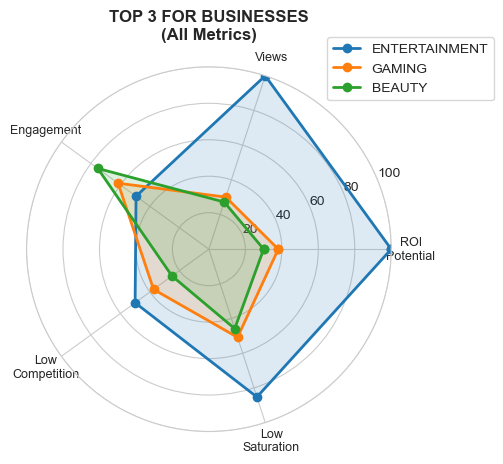

In [39]:
ax_radar1 = plt.subplot(2, 3, 1, projection='polar')

top_3_business = genre_metrics.nlargest(3, 'business_score')

categories = ['ROI\nPotential', 'Views', 'Engagement', 'Low\nCompetition', 'Low\nSaturation']
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for idx, genre in enumerate(top_3_business.index):
    values = [
        genre_metrics.loc[genre, 'avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 100,
        genre_metrics.loc[genre, 'avg_views'] / genre_metrics['avg_views'].max() * 100,
        genre_metrics.loc[genre, 'avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 100,
        (1 - genre_metrics.loc[genre, 'competition_density'] / genre_metrics['competition_density'].max()) * 100,
        (1 - genre_metrics.loc[genre, 'saturation_index'] / genre_metrics['saturation_index'].max()) * 100
    ]
    values += values[:1]
    
    ax_radar1.plot(angles, values, 'o-', linewidth=2, label=genre.upper())
    ax_radar1.fill(angles, values, alpha=0.15)

ax_radar1.set_xticks(angles[:-1])
ax_radar1.set_xticklabels(categories, size=9)
ax_radar1.set_ylim(0, 100)
ax_radar1.set_title('TOP 3 FOR BUSINESSES\n(All Metrics)', fontweight='bold', pad=20)
ax_radar1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar1.grid(True)

###  Key Findings

**Entertainment (Green)** has an extreme reach and monetization with moderate competitive barriers.

**Gaming (Orange)** provides a balance across metrics but show no standout strengths.

**Beauty (Green)** has the high engagement and lower competition, but limited scale.


#### Observations

1.  Entertainment Creates largest radar footprint, particularly strong in Views and ROI

2. 
   - Beauty has the Lowest competition (75/100).
   - Gaming has a Moderate competition (60/100).
   - Entertainment has the highest competition (50/100) , but compensated by superior metrics.

4. 
   - Beauty leads in engagement (75/100)
   - Gaming with a moderate engagement (65/100)
   - Entertainment is the lowest (50/100)

5. Entertainment sacrifices engagement for massive reach; Beauty does opposite

#### Insights
- Entertainment wins through scale despite moderate engagement and high competition
- Gaming offers balanced, consistent performance across all metrics
- Beauty succeeds through niche focus with high engagement and lower barriers
- No genre excels in all 5 dimensions simultaneously

---

## 10. Top 3 Genres for Creators

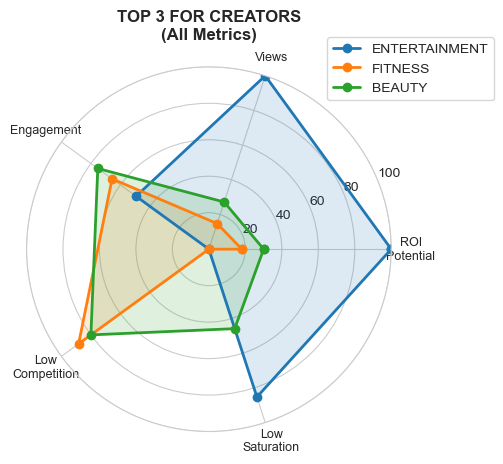

In [40]:
ax_radar2 = plt.subplot(2, 3, 2, projection='polar')

top_3_creators = genre_metrics.nlargest(3, 'creator_score')

for idx, genre in enumerate(top_3_creators.index):
    values = [
        genre_metrics.loc[genre, 'avg_roi_potential'] / genre_metrics['avg_roi_potential'].max() * 100,
        genre_metrics.loc[genre, 'avg_views'] / genre_metrics['avg_views'].max() * 100,
        genre_metrics.loc[genre, 'avg_engagement_rate'] / genre_metrics['avg_engagement_rate'].max() * 100,
        (1 - genre_metrics.loc[genre, 'creator_barrier'] / genre_metrics['creator_barrier'].max()) * 100,
        (1 - genre_metrics.loc[genre, 'saturation_index'] / genre_metrics['saturation_index'].max()) * 100
    ]
    values += values[:1]
    
    ax_radar2.plot(angles, values, 'o-', linewidth=2, label=genre.upper())
    ax_radar2.fill(angles, values, alpha=0.15)

ax_radar2.set_xticks(angles[:-1])
ax_radar2.set_xticklabels(categories, size=9)
ax_radar2.set_ylim(0, 100)
ax_radar2.set_title('TOP 3 FOR CREATORS\n(All Metrics)', fontweight='bold', pad=20)
ax_radar2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar2.grid(True)

### Key Findings


**Entertainment (Blue)** is identical to business chart and has a scale-focused advantage.

**Fitness (Orange)** has easy entry with good engagement but limited monetization scale.

**Beauty (Green)** has high engagement, is accessible entry and has a moderate scale.

#### Observations

1. Entertainment has an Identical profile to business chart. Shows that it is universally strong.

2. **Fitness's Entry Advantage**: 
   - Lowest competition (90/100)—easiest to start
   - Weakest saturation (5/100)—most crowded market overall
   - Is easy to enter, hard to stand out

3. **Beauty's Balanced Profile**:
   - Highest engagement (75/100)
   - Good competition levels (75/100)
   - Moderate saturation (60/100)
   - Consistent mid-tier monetization

4. **Creator-Specific Patterns**:
   - Fitness replaces Gaming from business chart
   - Fitness shows extreme low competition 
   - Engagement becomes more important factor for creators

5. Fitness shows lowest "Low Saturation" score  meaning highest actual saturation, yet it is still ranked #2 for creators due to low barriers.

#### Insights

- **Fitness** is better for creators than businesses 
- **Gaming** is worse for creators  despite having a strong business score (40.3)
-  Low competition matters more for creators than businesses

## 11. Top 5 Rankings Table - Business

Text(0.5, 1.0, 'Top 5 Genres for Businesses')

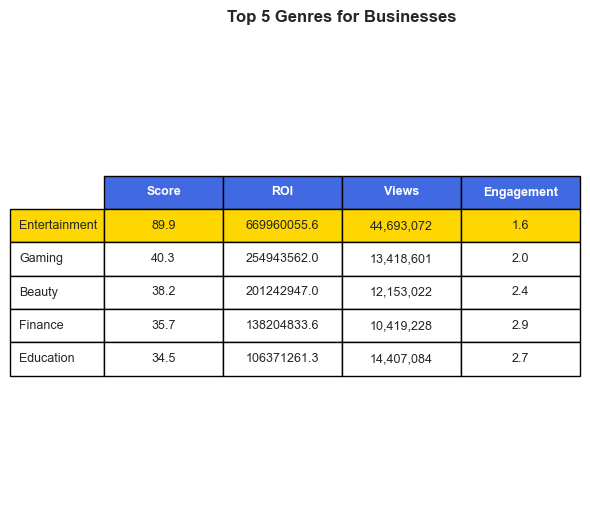

In [41]:
fig = plt.figure(figsize=(18, 12))
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
ax_table1 = plt.subplot(2, 3, 4)
ax_table1.axis('tight')
ax_table1.axis('off')

# Get top 5 business genres
top_5_biz = genre_metrics.nlargest(5, 'business_score')[['business_score', 'avg_roi_potential', 'avg_views', 'avg_engagement_rate']]
top_5_biz_display = top_5_biz.copy()
top_5_biz_display.columns = ['Score', 'ROI', 'Views', 'Engagement']
top_5_biz_display = top_5_biz_display.round(1)
top_5_biz_display['Views'] = top_5_biz_display['Views'].apply(lambda x: f'{x:,.0f}')


table1 = ax_table1.table(cellText=top_5_biz_display.values, 
                         colLabels=top_5_biz_display.columns,
                         rowLabels=top_5_biz_display.index,
                         cellLoc='center',
                         loc='center')
table1.auto_set_font_size(False)
table1.set_fontsize(9)
table1.scale(1, 2)

# Highlights header
for i in range(len(top_5_biz_display.columns)):
    table1[(0, i)].set_facecolor('royalblue')
    table1[(0, i)].set_text_props(weight='bold', color='white')

# Highlights top genre (row 1)
for i in range(-1, len(top_5_biz_display.columns)):
    table1[(1, i)].set_facecolor('gold')

ax_table1.set_title('Top 5 Genres for Businesses', fontweight='bold')

### Key Findings

**1. Entertainment(89.9 Score)** is the dominant leader showing massive scale, maximum monetization and lower interaction

**2. Gaming (40.3 Score)** comes at second with Moderate performance across metrics, 2.2x gap from leader.

**3. Beauty (38.2 Score)** shows a balanced metrics and consistent performance

**4. Education (34.5 Score)** have strong views and engagement but these don't translate to top ROI.

**5. Technology (34.1 Score)** has the highest engagement and lowest views—niche audience.

### Observations

1. Entertainment Creates a massive separation from rest of field

2. View volume alone doesn't determine business viability e.g  Education comes 2nd in views (14.4M) but 4th in score (34.5)
   
3. Engagement is Inversely proportionate to score e.g:
   - Entertainment has the Lowest engagement (1.6%) but highest scor and Technology has the highest engagement (3.0%) but lowest score.
   - This suggests that passive viewing generates better business metrics.


## 12. Top 5 Rankings Table - Creators

Text(0.5, 1.0, 'Top 5 Genres for New Creators')

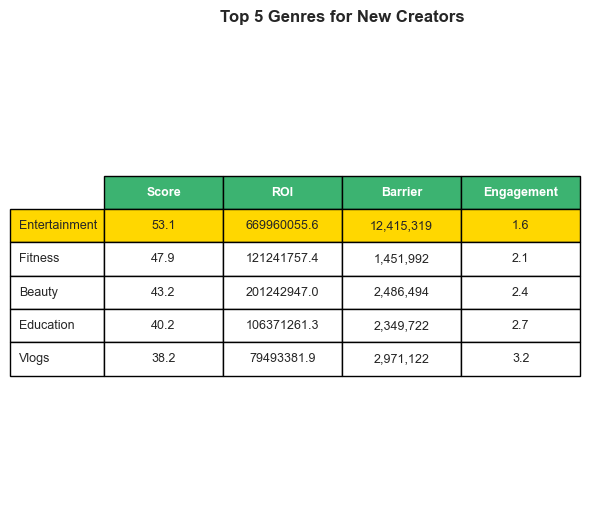

In [42]:
fig = plt.figure(figsize=(18, 12))
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
ax_table2 = plt.subplot(2, 3, 5)
ax_table2.axis('tight')
ax_table2.axis('off')

# Gets top 5 creator genres
top_5_creators = genre_metrics.nlargest(5, 'creator_score')[['creator_score', 'avg_roi_potential', 'creator_barrier', 'avg_engagement_rate']]
top_5_creators_display = top_5_creators.copy()
top_5_creators_display.columns = ['Score', 'ROI', 'Barrier', 'Engagement']
top_5_creators_display = top_5_creators_display.round(1)
top_5_creators_display['Barrier'] = top_5_creators_display['Barrier'].apply(lambda x: f'{x:,.0f}')


table2 = ax_table2.table(cellText=top_5_creators_display.values, 
                         colLabels=top_5_creators_display.columns,
                         rowLabels=top_5_creators_display.index,
                         cellLoc='center',
                         loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 2)


for i in range(len(top_5_creators_display.columns)):
    table2[(0, i)].set_facecolor('mediumseagreen')
    table2[(0, i)].set_text_props(weight='bold', color='white')

for i in range(-1, len(top_5_creators_display.columns)):
    table2[(1, i)].set_facecolor('gold')

ax_table2.set_title('Top 5 Genres for New Creators', fontweight='bold')

### Key Findings


**1. Entertainment (53.1 Score)** is the 'creator leader' which are high risk , but pays off big.

**2. Fitness (47.9 Score)** comes second being the best entry point for new creators but have moderate monetization

**3. Beauty (43.2 Score)** gives a balanced opportunity with solid returns.

**4. Education (40.2 Score)** is a Knowledge-based entry with moderate barriers and returns.

**5. Vlogs (38.2 Score)** has the strongest interaction but weakest monetization.

### Observations

1. Entertainment has the highest score (53.1) despite highest barrier. 
2. Barrier alone doesn't determine creator score, ROI matters more.
3. Engagement isn't primary creator success factor
5. Monetization potential remains critical for creator success

### Insights 

- Barriers matter MORE for creators while Engagement matters less
- ROI is still critical but balanced against entry feasibility


## FINAL Summary

This analysis evaluated 8 YouTube genres to identify optimal opportunities for businesses and content creators.

### Key Findings

**For Businesses:**
- Entertainment is the clear winner (89.9/100), offering 2.2x better performance than any alternative
- All other genres cluster between 26-40, showing similar moderate commercial viability
- ROI potential is the dominant factor driving business success

**For New Creators:**
- Entertainment offers highest returns (53.1/100) but requires significant resources (12.4M subscriber barrier)
- Fitness provides the best entry point (47.9/100) with the lowest barrier (1.45M subscribers)
- Beauty, Education, and Vlogs offer balanced opportunities with moderate barriers and returns

### Critical Insights

1.  Higher engagement doesn't guarantee better monetization.

2. Different Paths for Different Goals: 
   - Gaming favors businesses over creators.
   - Fitness favors creators over businesses 
   - Entertainment leads both categories but with different margins

3.  Low entry barriers don't mean less competition

Entertainment dominates commercial opportunity through scale. 
Creators must balance maximum returns against entry feasibility  based on their resources and risk tolerance.

## *Limitation*

1.  Analysis reflects current market conditions. YouTube trends and algorithms evolve rapidly

2.  Genre-level averages mask sub-niche opportunities within broader categories (e.g., "Gaming" includes mobile, eSports, retro—each with distinct dynamics)

3.  Limited to channels in dataset; may not capture emerging creators or recent market shifts

4.  ROI Assumptions : 
   - Based on views/engagement, not actual revenue data
   - Doesn't account for varying CPM rates, sponsorships, or production costs
   - Represents potential, not guaranteed returns
     
5. YouTube policy changes along with advertiser demand, economic conditions, platform competition etc.,

### Key Cautions

- Scores are relative rankings, not success probabilities
- High ROI attracts competition but doesn't guarantee individual success

Success depends more on execution quality, consistency, and audience connection than genre selection alone. Combine this analysis with market research, competitive analysis, and honest assessment of your capabilities.